In [ ]:
# --- Hardware Settings ---
USE_TPU = False  # Set to True to enable TPU support (requires TPU environment)

# Workshop: Tunix-Med · Part 3 — Supervised Fine-Tuning with JAX & Tunix

Welcome to the heart of the **Tunix-Med** workshop. In this notebook we fine-tune **Gemma 3** on a domain-specific cardiology Q&A dataset using a carefully engineered stack built on three modern technologies: **JAX**, **Tunix**, and (later, for evaluation) **vLLM**. Understanding each layer of this stack will make you a far more effective ML practitioner.

---

## What are JAX, Tunix, and vLLM?

### JAX
[JAX](https://github.com/google/jax) is Google’s high-performance numerical computing library. At its core, JAX is “NumPy on steroids”: it provides a nearly identical API to NumPy, but with four superpowers:
- **JIT compilation** via [XLA](https://openxla.org/xla): Python functions are traced and compiled into highly optimised hardware kernels for GPU/TPU. You write readable Python; XLA generates machine code comparable to hand-written CUDA.
- **Automatic differentiation** (`jax.grad`): Differentiates through arbitrary Python/NumPy code, including loops and conditionals.
- **Vectorised mapping** (`jax.vmap`): Applies a function in parallel across a batch dimension without writing explicit batch loops.
- **Parallel execution** (`jax.pmap` / device meshes): Distributes computation across multiple accelerators with minimal code changes.

Because JAX functions are compiled and stateless, they fit naturally onto TPU pods and multi-GPU servers — which is exactly what Tunix exploits.

### Tunix
[Tunix](https://github.com/google-deepmind/tunix) is a JAX-native supervised fine-tuning library built entirely on the JAX/Flax/Optax ecosystem:
- It provides a `PeftTrainer` that handles the full training loop (forward pass, loss, gradient accumulation, evaluation, checkpointing) **inside JIT-compiled steps**, yielding maximum throughput.
- It defines clean hook interfaces (`TrainingHooks`) so you can intercept training events — logging, early stopping, custom model export — without breaking XLA fusion.
- It supports PEFT methods (LoRA, etc.) out of the box, and its architecture is deliberately open so users can inject custom layers (as we do here for Einsum-based attention).

### vLLM
[vLLM](https://github.com/vllm-project/vllm) is a high-throughput LLM inference engine. It is not used during training, but in the **evaluation notebook** (Part 4) it serves the fine-tuned model for batch inference. Its key innovation is **PagedAttention** — a memory management scheme that stores the KV-cache in non-contiguous pages (similar to OS virtual memory), dramatically increasing the number of concurrent requests a single GPU can serve.

---

## Why this combination?

| Need | Solution |
|------|----------|
| Memory-efficient training on a single GPU | LoRA (only ≤2 % of weights trained) |
| Maximum GPU utilisation during training | JAX + XLA compilation via Tunix |
| Streaming data — never OOM on large datasets | Python generator → JAX arrays on-the-fly |
| Fast post-training evaluation | vLLM PagedAttention serving |

---

## Notebook roadmap

| Section | What happens |
|---------|-------------|
| §1 | Configure the JAX backend and suppress noisy logging |
| §2 | Define all hyper-parameters in one `Config` dataclass |
| §3 | Build a streaming tokenisation pipeline (no full-dataset RAM load) |
| §4 | Load Gemma 3 weights and inject custom LoRA into every attention layer |
| §5 | Define training hooks, gradient-norm capture, and the adapter export function |
| §6 | Run the training loop with early stopping |
| §7 | Plot train/validation loss and gradient norm |
| §8 | Push the LoRA adapter to the Hugging Face Hub |


## 1 · Environment & JAX Setup

Before importing any model code we configure two things:
1. **Memory allocation policy** — by default JAX pre-allocates ~90 % of GPU VRAM as a memory pool. We disable this so the evaluation model (vLLM, loaded later) can share the same device.
2. **Logging verbosity** — libraries like `absl`, `flax`, and `grain` are very chatty at `INFO` level. We silence them early so the notebook output stays readable.


### Deep Dive: The JAX Execution Model

Understanding how JAX runs code is essential to interpreting the training code that follows.

#### Eager vs. compiled execution
Standard Python/NumPy code runs **eagerly** — each operation executes immediately and returns a concrete array. JAX also runs eagerly by default (useful for debugging), but its real power comes from `@jax.jit`, which **traces** a function once and hands the resulting computation graph to the **XLA compiler**. XLA performs:
- **Operator fusion**: multiple element-wise ops are merged into a single GPU kernel, avoiding round-trips through GPU memory.
- **Layout optimisation**: tensors are reordered in memory to maximise cache hits.
- **Kernel auto-tuning**: XLA tries different tiling strategies and picks the fastest.

The first call to a JIT-compiled function is slow (compilation); subsequent calls with the same *shape* are blazing fast.

#### Functional purity and pytrees
JAX functions must be **pure** (no side effects, no mutation of external state). Model parameters, optimiser state, and random keys are all passed explicitly as function arguments. JAX represents these nested structures (dicts of arrays, lists of dicts, ...) uniformly as **pytrees** — it knows how to flatten and unflatten them automatically, which is what makes `jax.grad` and `jax.vmap` so composable.

#### Devices and meshes
```python
jax.devices()          # lists all accelerators visible to JAX
jax.device_put(x, d)   # move array x to device d
```
For multi-device parallelism, JAX uses a **`Mesh`** to assign named logical axes (`"tp"` for tensor parallelism, `"fsdp"` for fully-sharded data parallelism) to physical devices. Tunix uses a `(1, N)` mesh for single-node runs.

#### Key environment variables
| Variable | Effect |
|----------|--------|
| `XLA_PYTHON_CLIENT_PREALLOCATE=false` | Disable upfront VRAM reservation; allocate on demand |
| `XLA_PYTHON_CLIENT_MEM_FRACTION=0.85` | Alternative: reserve only 85 % at startup |
| `TF_CPP_MIN_LOG_LEVEL=3` | Suppress TensorFlow/XLA C++ warnings in stderr |


In [2]:
import os
import logging

# Prevent JAX from hogging all VRAM immediately
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

# Silence verbose library logging for a cleaner workshop experience
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
for _name in ("absl", "jax", "orbax", "flax", "datasets", "transformers", "grain"):
    logging.getLogger(_name).setLevel(logging.ERROR)

import jax
import jax.numpy as jnp
import numpy as np

if USE_TPU:
    # Initialize TPU distributed system if running on TPU VM or Colab
    try:
        if "COLAB_TPU_ADDR" in os.environ:
            import jax.tools.colab_tpu
            jax.tools.colab_tpu.setup_jax()
        else:
            jax.distributed.initialize()
        print("TPU initialized successfully.")
    except Exception as e:
        print(f"Warning: TPU initialization failed: {e}. Falling back to default backend.")

print(f"JAX backend : {jax.default_backend()}")
print(f"Devices     : {jax.devices()}")

JAX backend : gpu
Devices     : [CudaDevice(id=0)]


## 2 · Hyperparameter Configuration

All experiment settings live in a single `Config` dataclass. Centralising hyper-parameters this way is good practice — it makes experiments reproducible and lets you swap configurations without hunting through multiple cells.

> **Note on `MAX_STEPS`**: this value is computed in Cell 3 *after* we know how many training examples exist. Everything else is set here and remains constant throughout the notebook.

### Parameter guide

**Model & data**
- `MODEL_NAME`: the Hugging Face identifier of the *base* model to fine-tune.
- `MAX_SEQ_LEN`: all sequences are padded/truncated to this length. Longer → more context but quadratic attention memory cost.
- `EVAL_SPLIT`: fraction of data held out for validation (10 % here).

**LoRA settings**
- `LORA_RANK` (`r`): the bottleneck dimension of the low-rank matrices. Higher rank = more expressive adaptation but more trainable parameters. Common values: 8, 16, 32.
- `LORA_ALPHA` (α): a scaling factor. The effective contribution of the LoRA branch is `α/r × xAB`. Keeping `α = 2r` (as here) is a common heuristic that decouples the learning rate from the rank.
- `LORA_DROPOUT`: regularisation applied to the input of the LoRA branch only (frozen weights are unaffected).

**Optimisation**
- `LEARNING_RATE`: peak LR reached after the warm-up phase. Values around `1e-5`–5e-5` work well for instruction-tuned models.
- `WEIGHT_DECAY`: L2 regularisation coefficient applied via AdamW to prevent overfitting.
- `WARMUP_RATIO`: fraction of total steps used for linear warm-up before the cosine decay begins.

**Training loop**
- `BATCH_SIZE` × `GRAD_ACCUM_STEPS` = **effective batch size** (16 here). Gradient accumulation simulates a larger batch without requiring the memory to hold it all at once.
- `EARLY_STOP_PATIENCE`: if validation loss does not improve for this many consecutive evaluation checkpoints, training stops. This prevents overfitting and saves GPU time.


### Deep Dive: LoRA — Low-Rank Adaptation

#### The problem LoRA solves
Full fine-tuning updates every weight in the model. For a 1B-parameter model in `bfloat16`, that is ~2 GB of parameters *plus* at least ~4 GB of optimiser state (Adam maintains two momentum buffers per parameter). This easily exceeds available VRAM on a single consumer GPU.

#### The LoRA solution
LoRA (**Lo**w-**R**ank **A**daptation, [Hu et al., 2022](https://arxiv.org/abs/2106.09685)) observes that the *update* to a weight matrix during fine-tuning has **low intrinsic rank** — most of the information can be captured by a much smaller matrix. Instead of updating $W$ directly, LoRA freezes $W$ and adds a **parallel branch**:

$$\text{output} = xW + \frac{\alpha}{r} \cdot x \underbrace{AB}_{\Delta W}$$

where $A \in \mathbb{R}^{d \times r}$ and $B \in \mathbb{R}^{r \times k}$ with $r \ll \min(d, k)$.

- $A$ is initialised with small random Gaussian values; $B$ is initialised to **zero** so the branch has no effect at the start of training.
- Only $A$ and $B$ are trained; $W$ is frozen.
- At inference time the branch can be **merged** back: $W' = W + \frac{\alpha}{r} AB$, adding zero latency.

#### Why the scale factor matters
The factor $\alpha/r$ decouples the learning rate from the rank choice: you can change `r` without re-tuning the learning rate, as long as you keep `α` proportional to `r`.

#### Parameter count comparison
For a single attention projection with $d = k = 2048$ and $r = 16$:
- **Full fine-tuning**: $2048 \times 2048 = 4{,}194{,}304$ parameters
- **LoRA**: $2 \times 2048 \times 16 = 65{,}536$ parameters — **64× fewer**

Across all layers of a 270M-parameter model, LoRA typically trains fewer than 5M parameters in total.


In [3]:
class Config:
    MODEL_NAME = "google/gemma-3-270M-it"
    MODEL_KEY = "gemma-3-270M-it"
    TUNED_MODEL_NAME = f"lmassaron/{MODEL_KEY}-medical-cardiology-lora"

    DATASET_PATH = "data/medical-cardiology-qa"
    MAX_SEQ_LEN = 1024
    EVAL_SPLIT = 0.1
    SEED = 42

    # LoRA
    LORA_RANK = 16
    LORA_ALPHA = 32
    LORA_DROPOUT = 0.05

    # Optimisation
    LEARNING_RATE = 3e-5
    WEIGHT_DECAY = 0.01
    WARMUP_RATIO = 0.10

    # Training loop
    BATCH_SIZE = 4
    GRAD_ACCUM_STEPS = 4
    NUM_EPOCHS = 3
    EARLY_STOP_PATIENCE = 3
    EVAL_EVERY_N_STEPS = 100
    LOG_EVERY_N_STEPS = 100
    OUTPUT_DIR = "tunix-medical-model"

    # Computed after the dataset is loaded
    MAX_STEPS: int = 0


params = Config()
print(f"Effective Batch Size: {params.BATCH_SIZE * params.GRAD_ACCUM_STEPS}")

Effective Batch Size: 16


## 3 · Streaming Data Pipeline

Loading an entire dataset into RAM before training is wasteful and sometimes impossible. Instead, we build a **streaming generator** that:
1. Shuffles indices (not the dataset itself) — no data copying.
2. Pulls examples one at a time from the HuggingFace `datasets` object.
3. Tokenises on-the-fly and pads to `MAX_SEQ_LEN`.
4. Yields `TrainingInput` objects carrying JAX arrays directly, ready for the XLA-compiled training step.

### Chat template and loss masking
We use the tokeniser’s **chat template** to format each conversation into the exact token sequence the model was pre-trained to expect. Loss is computed only over **assistant turns** — the `input_mask` array marks which token positions contribute to the cross-entropy loss:
- `mask[i] = 0` → system / user prompt tokens (no gradient signal, model just reads them)
- `mask[i] = 1` → assistant response tokens (gradient flows through here)

This is critical for instruction tuning: we want the model to learn *how to respond*, not to memorise the questions.

### Why a Python generator works well with JAX
Because Tunix’s `trainer.train(train_iter, ...)` expects a plain Python iterable, we can interleave Python-side pre-processing (tokenisation, shuffling) with JAX-side computation (forward pass, gradient computation) without additional synchronisation overhead. The Python GIL is released during JAX’s GPU kernels, so both stages overlap naturally.


In [4]:
import datasets
from datasets import load_dataset
from transformers import AutoTokenizer
from tunix.sft import peft_trainer

hf_tokenizer = AutoTokenizer.from_pretrained(params.MODEL_NAME)
full_ds = load_dataset("lmassaron/medical-cardiology-qa", split="train")
n = len(full_ds)

# Reproducible train / eval split
rng = np.random.default_rng(params.SEED)
all_idx = rng.permutation(n)
cut = int(n * (1.0 - params.EVAL_SPLIT))
train_idx, eval_idx = all_idx[:cut], all_idx[cut:]

# ── Compute MAX_STEPS now that we know the dataset size ──────────────────────
_steps_per_epoch = len(train_idx) // params.BATCH_SIZE
params.MAX_STEPS = (_steps_per_epoch * params.NUM_EPOCHS)
print(f"Dataset    : {n:,} rows  |  Train: {len(train_idx):,}  Eval: {len(eval_idx):,}")
print(
    f"MAX_STEPS  : {params.MAX_STEPS}  (warmup: {int(params.MAX_STEPS * params.WARMUP_RATIO)})"
)

Dataset    : 5,722 rows  |  Train: 5,149  Eval: 573
MAX_STEPS  : 3861  (warmup: 386)


In [5]:
def _tokenise(example):
    messages = example["messages"]
    full_ids = hf_tokenizer.apply_chat_template(messages, tokenize=True)
    prompt_ids = hf_tokenizer.apply_chat_template(
        messages[:-1], tokenize=True, add_generation_prompt=True
    )
    # Extract IDs if it's a BatchEncoding
    if hasattr(full_ids, "input_ids"):
        full_ids = full_ids["input_ids"]
    if hasattr(prompt_ids, "input_ids"):
        prompt_ids = prompt_ids["input_ids"]

    prompt_len = len(prompt_ids)
    full_ids = full_ids[: params.MAX_SEQ_LEN]

    mask = np.ones(len(full_ids), dtype=np.int32)
    mask[: min(prompt_len, len(full_ids))] = 0

    pad_len = params.MAX_SEQ_LEN - len(full_ids)
    tokens = np.pad(
        full_ids, (0, pad_len), constant_values=hf_tokenizer.pad_token_id
    ).astype(np.int32)
    mask = np.pad(mask, (0, pad_len), constant_values=0).astype(np.int32)
    return {"input_tokens": tokens, "input_mask": mask}


def make_data_iterator(dataset, indices, batch_size, shuffle=True, infinite=True):
    while True:
        idxs = indices.copy()
        if shuffle:
            np.random.shuffle(idxs)
        for start in range(0, len(idxs) - batch_size + 1, batch_size):
            batch_idx = idxs[start : start + batch_size]
            processed = [_tokenise(dataset[int(i)]) for i in batch_idx]
            tokens = np.stack([p["input_tokens"] for p in processed])
            masks = np.stack([p["input_mask"] for p in processed])
            yield peft_trainer.TrainingInput(
                input_tokens=jnp.array(tokens),
                input_mask=jnp.array(masks),
            )
        if not infinite:
            break


train_iter = make_data_iterator(full_ds, train_idx, params.BATCH_SIZE)
print("Streaming data pipeline configured.")

Streaming data pipeline configured.


## 4 · Model Loading & Custom LoRA Injection

### Loading Gemma 3 with Tunix

We use `tunix.models.automodel` to:
1. **Download** the Gemma 3 weights from the Hugging Face Hub via `snapshot_download`.
2. **Reconstruct** the Flax/NNX model graph from the `.safetensors` shards.
3. **Load** the weights onto the device mesh in `bfloat16` precision — half the memory of `float32` with negligible accuracy loss for fine-tuning.

The `Mesh` object tells JAX how to shard tensors across available devices. Even on a single GPU we use a `(1, 1)` mesh to keep the code device-agnostic — scaling to more GPUs only requires changing the mesh shape.

### Why we need custom LoRA layers

Standard LoRA libraries (e.g. HuggingFace PEFT) target `nn.Linear` layers. Gemma 3’s multi-head attention, however, uses **Einstein summation** (`nnx.Einsum`) for its projection operations. A standard `LinearLoRALayer` cannot be grafted onto an `Einsum` module because the weight layout differs:
- `Linear.weight` shape: `(in_features, out_features)` — a 2-D matrix.
- `Einsum.w` shape: varies, e.g. `(num_heads, head_dim, model_dim)` — a 3-D tensor.

We therefore implement two custom wrappers:
- **`LinearLoRALayer`** — wraps `nnx.Linear`, applies $xAB$ as a standard matrix product.
- **`EinsumLoRALayer`** — wraps `nnx.Einsum`, flattens the weight tensor’s leading dimensions, applies the low-rank update, reshapes back, and re-runs the Einstein summation.

The `apply_lora` function walks the entire model graph using `nnx.graph.iter_graph` and replaces every `Linear` and `Einsum` it finds with the corresponding LoRA wrapper in-place.


### Deep Dive: Einstein Summation and LoRA

#### What is `einsum`?
Einstein summation notation provides a concise way to express any contraction of multi-dimensional tensors. For example, the string `"bsd,dhk->bshk"` means:
- Indices `b` (batch), `s` (sequence), `d` (model dim) come from the input tensor.
- Indices `d`, `h` (num heads), `k` (head dim) come from the weight tensor.
- The output has indices `b`, `s`, `h`, `k` — a multi-head projection.

`jax.numpy.einsum` (and `flax.nnx.Einsum`) are compiled by XLA into fused matrix multiplication kernels — effectively `matmul` under the hood but with automatic shape handling.

#### Why LoRA for Einsum requires special treatment
For a standard linear layer $y = xW$, the LoRA update is simply:

$$\Delta y = \frac{\alpha}{r} \cdot xAB$$

where $A$ and $B$ are 2-D matrices. For an einsum layer $y = \text{einsum}(\texttt{str}, x, W)$ with $W$ being a 3-D tensor, we cannot directly apply 2-D matrix multiplication. Our `EinsumLoRALayer` handles this by:
1. **Flattening** $W$: treat all leading dimensions as a single input dimension.
2. Computing the low-rank update $\Delta W = AB$ in the flattened space.
3. **Reshaping** $\Delta W$ back to the original tensor shape.
4. Re-running the einsum: $\Delta y = \text{einsum}(\texttt{str}, x, \Delta W)$.

This is mathematically equivalent to the standard LoRA formula and ensures that gradients flow through the correct axes of the attention weight tensor.


In [6]:
from flax import nnx
from tunix.models import automodel
from huggingface_hub import snapshot_download

# Build model on a 1-D mesh (single-GPU or single-TPU)
devices = np.array(jax.devices()).reshape((1, -1))
mesh = jax.sharding.Mesh(devices, axis_names=("tp", "fsdp"))
model_path = snapshot_download(params.MODEL_NAME)
model_config = automodel.call_model_config(params.MODEL_KEY)

with mesh:
    model = automodel.create_model_from_safe_tensors(
        params.MODEL_KEY, model_path, model_config, mesh, dtype=jnp.bfloat16
    )

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

In [7]:
# ── Custom LoRA wrappers for Linear and Einsum layers ────────────────────────
class LinearLoRALayer(nnx.Module):
    def __init__(
        self, linear_module, rank, alpha, dropout, dtype=jnp.bfloat16, rngs=None
    ):
        self.linear = linear_module
        self.rank = rank
        self.scale = alpha / rank
        self.dropout = nnx.Dropout(dropout, rngs=rngs)

        in_features = linear_module.in_features
        out_features = linear_module.out_features

        self.lora_a = nnx.LoRAParam(
            jax.random.normal(rngs.params(), (in_features, rank), dtype=dtype) * 0.01
        )
        self.lora_b = nnx.LoRAParam(jnp.zeros((rank, out_features), dtype=dtype))

    def __call__(self, x):
        base = self.linear(x)
        lora = (self.dropout(x) @ self.lora_a[...] @ self.lora_b[...]) * self.scale
        return base + lora.astype(x.dtype)


class EinsumLoRALayer(nnx.Module):
    def __init__(
        self, einsum_module, rank, alpha, dropout, dtype=jnp.bfloat16, rngs=None
    ):
        self.einsum = einsum_module
        self.rank = rank
        self.scale = alpha / rank
        self.dropout = nnx.Dropout(dropout, rngs=rngs)

        w = einsum_module.w
        in_dim = int(np.prod(w.shape[:-1]))
        out_dim = w.shape[-1]

        self.lora_a = nnx.LoRAParam(
            jax.random.normal(rngs.params(), (in_dim, rank), dtype=dtype) * 0.01
        )
        self.lora_b = nnx.LoRAParam(jnp.zeros((rank, out_dim), dtype=dtype))

    def __call__(self, x):
        base = self.einsum(x)
        delta_w = (self.lora_a[...] @ self.lora_b[...]).reshape(self.einsum.w.shape)
        return base + self.scale * jnp.einsum(
            self.einsum.einsum_str, self.dropout(x), delta_w.astype(x.dtype)
        )


def _get_child(parent, key):
    try:
        return getattr(parent, str(key))
    except AttributeError:
        return parent[int(key)]


def _set_child(parent, key, value):
    try:
        setattr(parent, str(key), value)
    except (AttributeError, TypeError):
        parent[int(key)] = value


def apply_lora(model, rank, alpha, dropout):
    replaced = 0
    rngs = nnx.Rngs(params=0, dropout=0)
    for path, mod in nnx.graph.iter_graph(model):
        if not path:
            continue
        parent = model
        try:
            for step in path[:-1]:
                parent = _get_child(parent, step)
            attr = path[-1]
        except Exception:
            continue

        if isinstance(mod, nnx.Linear):
            _set_child(
                parent, attr, LinearLoRALayer(mod, rank, alpha, dropout, rngs=rngs)
            )
            replaced += 1
        elif isinstance(mod, nnx.Einsum):
            _set_child(
                parent, attr, EinsumLoRALayer(mod, rank, alpha, dropout, rngs=rngs)
            )
            replaced += 1
    return replaced


with mesh:
    n_lora = apply_lora(model, params.LORA_RANK, params.LORA_ALPHA, params.LORA_DROPOUT)
print(f"Patched {n_lora} layers with LoRA.")

Patched 54 layers with LoRA.


## 5 · Training Hooks, Gradient Capture & Adapter Export

This section defines the scaffolding around the core training loop:

1. **`export_adapter`** — serialises only the LoRA weight matrices (not the frozen base model) to a PEFT-compatible `adapter_model.safetensors` file.
2. **`capture_grad_norm`** — a custom stateless `optax` transform that records the global gradient norm *inside* the XLA-compiled training step using `jax.experimental.io_callback`.
3. **`CleanProgressHook`** — a Tunix `TrainingHooks` subclass that logs metrics, saves the best checkpoint, and triggers early stopping.

### The adapter export format
We save LoRA weights in the format expected by [HuggingFace PEFT](https://github.com/huggingface/peft):
- `adapter_config.json`: metadata (base model name, rank, alpha, target modules).
- `adapter_model.safetensors`: the actual $A$ and $B$ matrices, keyed by PEFT-style path names (e.g. `base_model.model.model.layers.0.self_attn.q_proj.lora_A.weight`).

> **Note on transpose**: JAX stores weight matrices as `(in, rank)` / `(rank, out)`, while PEFT expects `(rank, in)` / `(out, rank)`. We apply `.T` during export to match the convention.

### How gradient norm crosses the JIT boundary
JAX JIT compilation erases Python-side state — you cannot simply append to a list inside a compiled function. `jax.experimental.io_callback` is the sanctioned escape hatch: it schedules a Python callable to be invoked with the value of a JAX array, **synchronously** within the compiled step. We use `ordered=True` to guarantee one callback per gradient-update step (after `GRAD_ACCUM_STEPS` micro-batches), which aligns with the `on_train_step_end` hook cadence.

> **Why capture the norm before clipping?** Gradient clipping changes the norm by definition. The pre-clip norm is the more informative diagnostic: a steadily rising pre-clip norm with a capped effective norm indicates your learning rate may be too high or your model may be diverging.


### Deep Dive: JAX, JIT, and the Hook Boundary

#### Why you cannot `print` inside a JAX training loop
When Tunix’s `PeftTrainer.train()` runs, the inner loop body is wrapped in `@jax.jit`. At trace time, JAX records *operations* on abstract values — it does not execute them. A `print` statement in the loop body would fire exactly once during tracing (printing an abstract shape, not a number) and never again during subsequent steps.

#### The hook API as a JIT boundary
Tunix’s `TrainingHooks.on_train_step_end(train_ctx, step, loss, step_time)` is called **outside** the JIT region — it receives concrete Python/NumPy scalars. This is the safe place to:
- Log metrics to stdout, TensorBoard, or W&B.
- Decide whether to checkpoint or stop early.
- Read data written by `io_callback` (like our gradient norm list).

#### `sys.stdout.flush()` in Jupyter
Jupyter captures stdout and displays it in the output cell. Without `flush()`, buffered lines accumulate invisibly and are printed all at once when the buffer fills or training ends — making it look like nothing is happening. Flushing after every log line gives real-time feedback during long training runs.

#### Perplexity as a training diagnostic
**Perplexity** (PPL) is $e^{\text{loss}}$, where loss is the mean per-token cross-entropy. It represents the effective “vocabulary size” the model is uncertain over at each token. Lower is better:
- PPL $\approx$ 1 → model is perfectly certain (memorisation — bad for generalisation).
- PPL $\approx$ 10 → model assigns ~10 % probability to the correct next token on average.
- PPL $\approx$ 100+ → model is very uncertain; likely undertrained or misconfigured.

For instruction-tuned models fine-tuned on domain data, a final train PPL in the range **3–15** is typical.


In [8]:
import math
import optax
import time
import jax
import jax.numpy as jnp
from tunix.sft import hooks


def export_adapter(model, cfg):
    import os, json, safetensors.flax as stf
    from flax import nnx

    os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

    config = {
        "base_model_name_or_path": cfg.MODEL_NAME,
        "lora_alpha": cfg.LORA_ALPHA,
        "lora_dropout": cfg.LORA_DROPOUT,
        "r": cfg.LORA_RANK,
        "target_modules": [
            "q_proj",
            "k_proj",
            "v_proj",
            "o_proj",
            "gate_proj",
            "up_proj",
            "down_proj",
        ],
        "peft_type": "LORA",
        "task_type": "CAUSAL_LM",
        "bias": "none",
    }
    with open(os.path.join(cfg.OUTPUT_DIR, "adapter_config.json"), "w") as f:
        json.dump(config, f, indent=2)

    lora_weights = {}
    from flax import nnx as _nnx

    for path, leaf in _nnx.graph.iter_graph(model):
        if not isinstance(leaf, (_nnx.Param, _nnx.LoRAParam)):
            continue
        key = ".".join(str(p) for p in path)
        if "lora" not in key.lower():
            continue
        peft_key = "base_model.model.model." + key
        peft_key = (
            peft_key.replace(".lora_a", ".lora_A.weight")
            .replace(".lora_b", ".lora_B.weight")
            .replace(".value", "")
        )
        lora_weights[peft_key] = leaf[
            ...
        ].T  # JAX(in,rank)->(rank,in) / (rank,out)->(out,rank) for PEFT

    if lora_weights:
        stf.save_file(
            lora_weights,
            os.path.join(cfg.OUTPUT_DIR, "adapter_model.safetensors"),
        )
        print(f"  Adapter saved → {cfg.OUTPUT_DIR}/adapter_model.safetensors")

In [9]:
# ── Gradient-norm capture via a custom optax transform ───────────────────────
# tunix's on_train_step_end hook receives (train_ctx, step, loss, step_time)
# and does NOT expose gradient norm.  We inject a stateless optax transform
# that runs *inside* the JIT-compiled step and writes the pre-clip global norm
# to a Python list via jax.experimental.io_callback.

_grad_norm_capture: list[float] = []  # written inside JIT, read in hook


def _store_norm(norm_scalar: jnp.ndarray) -> None:
    """Python callback: appends the gradient norm captured from inside JIT."""
    _grad_norm_capture.append(float(norm_scalar))


def capture_grad_norm() -> optax.GradientTransformation:
    """
    A stateless optax transform that records the global gradient norm
    (BEFORE any clipping) via jax.experimental.io_callback.

    Place this transform first in an optax.chain() so it sees raw gradients.
    Because tunix wraps the user-supplied optimizer with optax.MultiSteps
    internally, this callback fires once per actual weight update (i.e. every
    GRAD_ACCUM_STEPS micro-batches), which is exactly the right cadence to
    match on_train_step_end.
    """

    def init_fn(params):
        return optax.EmptyState()

    def update_fn(updates, state, params=None):
        norm = optax.global_norm(updates)
        # ordered=True ensures the Python side sees one norm per train step
        jax.experimental.io_callback(_store_norm, None, norm, ordered=True)
        return updates, state

    return optax.GradientTransformation(init_fn, update_fn)

In [10]:
# ── CleanProgressHook ─────────────────────────────────────────────────────────
import sys

class CleanProgressHook(hooks.TrainingHooks):
    """
    Logs loss, perplexity, and gradient norm at every log step.
    Saves the best adapter only when eval loss actually improves.
    Raises StopIteration for early stopping.

    Perplexity: exp(mean_loss) over all tokens in the batch/split.
    Gradient norm: read from _grad_norm_capture after each train step.
    """

    def __init__(
        self,
        log_every,
        max_steps,
        steps_per_epoch,
        eval_idx_ref,
        model,
        params,
        export_fn,
        patience=5,
    ):
        self._log_every = log_every
        self._max_steps = max_steps
        self._steps_per_epoch = max(1, steps_per_epoch)
        self._eval_idx = eval_idx_ref
        self._model = model
        self._params = params
        self._export_fn = export_fn
        self._patience = patience
        self._best_loss = float("inf")
        self._no_improve = 0
        self._t0 = time.time()
        self._step = 0
        # History lists for post-training plots
        self.train_loss_history = []  # [(step, loss), ...]
        self.eval_loss_history = []  # [(step, loss), ...]
        self.grad_norm_history = []  # [(step, grad_norm), ...]

    def on_train_start(self, train_ctx):
        pass

    def on_train_end(self, train_ctx):
        pass

    def on_train_step_start(self, train_ctx):
        pass

    def on_eval_step_start(self, train_ctx):
        pass

    def on_train_step_end(self, train_ctx, train_step, train_loss, step_time):
        # tunix hook API: (train_ctx, step, loss, step_time) — no grad_norm arg
        self._step = train_step
        loss_val = float(train_loss)
        ppl = math.exp(min(loss_val, 20.0))  # exp(mean_loss)

        self.train_loss_history.append((self._step, loss_val))

        # Read gradient norm captured by the optax transform (if available)
        if _grad_norm_capture:
            grad_norm = _grad_norm_capture[-1]
            _grad_norm_capture.clear()
            self.grad_norm_history.append((self._step, grad_norm))
        else:
            grad_norm = None

        if self._step % self._log_every == 0:
            epoch = self._step / self._steps_per_epoch
            elapsed = time.time() - self._t0
            gn_str = f"  grad_norm={grad_norm:.4f}" if grad_norm is not None else ""
            print(
                f"  step {self._step:>5}/{self._max_steps}"
                f"  epoch={epoch:.2f}"
                f"  loss={loss_val:.4f}"
                f"  ppl={ppl:.2f}"
                f"{gn_str}"
                f"  elapsed={elapsed:.0f}s"
            )
            sys.stdout.flush()

    def on_eval_step_end(self, train_ctx, eval_loss):
        n_complete_batches = max(1, len(self._eval_idx) // self._params.BATCH_SIZE)
        mean_loss = float(eval_loss) / n_complete_batches
        mean_ppl = math.exp(min(mean_loss, 20.0))   # exp(mean_loss)
        self.eval_loss_history.append((self._step, mean_loss))

        if mean_loss < self._best_loss:
            self._best_loss = mean_loss
            self._no_improve = 0
            self._export_fn(self._model, self._params)
            print(
                f"  [eval] step {self._step}"
                f"  loss={mean_loss:.4f}  ppl={mean_ppl:.2f} ↓ — Adapter saved!"
            )
        else:
            self._no_improve += 1
            print(
                f"  [eval] step {self._step}"
                f"  loss={mean_loss:.4f}  ppl={mean_ppl:.2f}"
                f"  (Best: {self._best_loss:.4f})"
                f"  No improvement {self._no_improve}/{self._patience}"
            )
        sys.stdout.flush()
        if self._no_improve >= self._patience:
            raise StopIteration

In [11]:
# ── Scheduler & Optimizer ────────────────────────────────────────────────────
schedule = optax.warmup_cosine_decay_schedule(
    0.0,
    params.LEARNING_RATE,
    int(params.MAX_STEPS * params.WARMUP_RATIO),
    params.MAX_STEPS,
)

# capture_grad_norm() MUST come first so it sees raw (un-clipped) gradients.
# clip_by_global_norm(1.0) is good practice to keep training stable.
optimizer = optax.chain(
    capture_grad_norm(),  # ← records pre-clip global norm
    optax.clip_by_global_norm(1.0),  # ← standard gradient clipping
    optax.adamw(
        learning_rate=schedule,
        weight_decay=params.WEIGHT_DECAY,
    ),
)

In [12]:
# ── Hook ─────────────────────────────────────────────────────────────────────
_steps_per_epoch = len(train_idx) // params.BATCH_SIZE

hook = CleanProgressHook(
    log_every=params.LOG_EVERY_N_STEPS,
    max_steps=params.MAX_STEPS,
    steps_per_epoch=_steps_per_epoch,
    eval_idx_ref=eval_idx,
    model=model,
    params=params,
    export_fn=export_adapter,
    patience=params.EARLY_STOP_PATIENCE,
)


def gen_model_input(training_input):
    from tunix.sft import utils as sft_utils

    tokens = training_input.input_tokens
    mask = training_input.input_mask
    positions = sft_utils.build_positions_from_mask(mask)
    attention_mask = sft_utils.make_causal_attn_mask(mask)
    return {
        "input_tokens": tokens,
        "input_mask": mask,
        "positions": positions,
        "attention_mask": attention_mask,
    }


trainer = peft_trainer.PeftTrainer(
    model,
    optimizer,
    peft_trainer.TrainingConfig(
        max_steps=params.MAX_STEPS,
        eval_every_n_steps=params.EVAL_EVERY_N_STEPS,
        gradient_accumulation_steps=params.GRAD_ACCUM_STEPS,
    ),
)
trainer.with_training_hooks(hook)
trainer.with_gen_model_input_fn(gen_model_input)
print("Trainer ready.")

Trainer ready.


## 6 · Execute Training

Everything is assembled — model, LoRA layers, optimiser, hooks, data iterators. This cell calls `trainer.train()` and the loop begins.

### What happens under the hood

```python
trainer.train(train_iter, ReusableEvalIter())
```

1. **Compile** (first step only): Tunix traces the forward+backward pass through XLA. This takes 30–90 s on first run. Subsequent steps are fast.
2. **Micro-batch loop**: for each of `GRAD_ACCUM_STEPS` micro-batches, a forward pass computes the per-token cross-entropy loss (masked to assistant tokens only) and accumulates gradients.
3. **Gradient update**: after accumulation, `capture_grad_norm` fires (recording the norm via `io_callback`), gradients are clipped to global norm 1.0, and AdamW applies the parameter update.
4. **Evaluation** (every `EVAL_EVERY_N_STEPS`): the eval iterator is consumed once; the hook computes mean eval loss and decides whether to save the adapter.
5. **Early stopping**: if `EARLY_STOP_PATIENCE` evaluations pass without improvement, the hook raises `StopIteration`, which is caught here.

### Scheduler: warm-up + cosine decay
The learning rate follows `optax.warmup_cosine_decay_schedule`:
- **Warm-up phase** (first `WARMUP_RATIO × MAX_STEPS` steps): LR rises linearly from 0 to `LEARNING_RATE`. This prevents large early updates from destabilising the pre-trained weights.
- **Cosine decay phase**: LR smoothly decreases toward 0, allowing the model to settle into a good minimum without oscillating.

### `ReusableEvalIter`
JAX/Tunix consumes the eval iterator to completion at each evaluation point. A plain Python generator would be exhausted after the first eval. We wrap the factory function in a class whose `__iter__` method creates a *fresh* generator each time — so every evaluation checkpoint sees the full eval set.


In [13]:
import traceback

class ReusableEvalIter:
    def __iter__(self):
        return make_data_iterator(
            full_ds, eval_idx, params.BATCH_SIZE, shuffle=False, infinite=False
        )


with mesh:
    try:
        trainer.train(train_iter, ReusableEvalIter())
    except StopIteration:
        print("Early stopping triggered.")
    except Exception as e:
        traceback.print_exc()
        raise

print(f"Training complete. Best adapter saved in: {params.OUTPUT_DIR}")

  Adapter saved → tunix-medical-model/adapter_model.safetensors
  [eval] step 0  loss=8.9496  ppl=7704.73 ↓ — Adapter saved!


Training:   0%|          | 0/3861 [00:00<?, ?step/s]

  Adapter saved → tunix-medical-model/adapter_model.safetensors
  [eval] step 99  loss=6.7920  ppl=890.73 ↓ — Adapter saved!
  step   100/3861  epoch=0.08  loss=6.8254  ppl=920.96  grad_norm=17.8750  elapsed=259s
  Adapter saved → tunix-medical-model/adapter_model.safetensors
  [eval] step 199  loss=4.1173  ppl=61.40 ↓ — Adapter saved!
  step   200/3861  epoch=0.16  loss=4.1762  ppl=65.12  grad_norm=4.9375  elapsed=363s
  Adapter saved → tunix-medical-model/adapter_model.safetensors
  [eval] step 299  loss=3.3254  ppl=27.81 ↓ — Adapter saved!
  step   300/3861  epoch=0.23  loss=3.5610  ppl=35.20  grad_norm=4.9688  elapsed=467s
  Adapter saved → tunix-medical-model/adapter_model.safetensors
  [eval] step 399  loss=3.0165  ppl=20.42 ↓ — Adapter saved!
  step   400/3861  epoch=0.31  loss=2.9703  ppl=19.50  grad_norm=2.9844  elapsed=572s
  Adapter saved → tunix-medical-model/adapter_model.safetensors
  [eval] step 499  loss=2.8782  ppl=17.78 ↓ — Adapter saved!
  step   500/3861  epoch=0.39

## 7 · Training Curves

Visualising training dynamics is essential for diagnosing problems and understanding model behaviour. We produce a two-panel figure:

### Panel 1 — Loss curves
- **Train loss** (blue, downsampled 10×): cross-entropy averaged over each micro-batch. Noisy due to small batch size, but the trend should be clearly downward.
- **Validation loss** (red, dashed): mean loss over the entire eval split, computed every `EVAL_EVERY_N_STEPS` steps. A smooth, decreasing curve indicates good generalisation; a curve that rises while train loss falls indicates **overfitting**.
- Both axes use a **log scale** to make small improvements at low loss values visible.

### Panel 2 — Gradient norm
The **global gradient norm** is the Euclidean norm of all gradients stacked into a single vector:

$$\|g\| = \sqrt{\sum_{i} g_i^2}$$

How to read it:
- A **stable norm** (roughly flat on log scale) → healthy training.
- **Spikes** → numerical instability; consider reducing the learning rate or gradient clip value.
- **Monotonically increasing** norm → the model may be diverging; check the loss curve.
- **Monotonically decreasing** norm (near zero) → the model has stopped learning; LR may be too low.

### The `downsample` helper
Train loss is recorded every step (potentially thousands of points). Plotting all of them makes the chart slow and the line visually jagged. `downsample(x, y, k=10)` keeps every 10th point for the train curve while keeping the eval curve dense (eval is already sparse by design).


In [14]:
def downsample(x, y, k=10):
    return x[::k], y[::k]

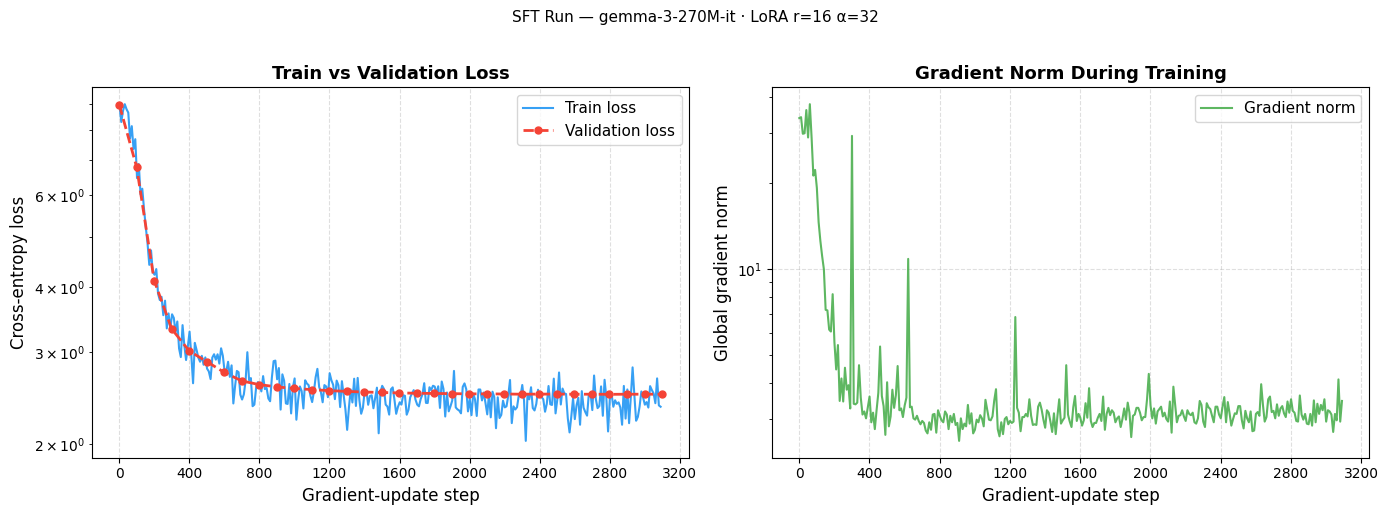

Figure saved → training_curves.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

train_steps, train_losses = (
    zip(*hook.train_loss_history) if hook.train_loss_history else ([], [])
)
eval_steps, eval_losses = (
    zip(*hook.eval_loss_history) if hook.eval_loss_history else ([], [])
)
gn_steps, gn_vals = zip(*hook.grad_norm_history) if hook.grad_norm_history else ([], [])

has_grad_norm = len(gn_steps) > 0
n_panels = 2 if has_grad_norm else 1

fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 5))
if n_panels == 1:
    axes = [axes]

# ── Panel 1 · Loss ────────────────────────────────────────────────────────────
train_steps_ds, train_losses_ds = downsample(train_steps, train_losses, k=10)
eval_steps_ds, eval_losses_ds = downsample(
    eval_steps, eval_losses, k=1
)  # keep eval dense

ax = axes[0]
if train_losses:
    ax.plot(
        train_steps_ds,
        train_losses_ds,
        label="Train loss",
        color="#2196F3",
        lw=1.5,
        alpha=0.9,
    )
if eval_losses:
    ax.plot(
        eval_steps_ds,
        eval_losses_ds,
        label="Validation loss",
        color="#F44336",
        lw=2,
        linestyle="--",
        marker="o",
        markersize=5,
    )

ax.set_xlabel("Gradient-update step", fontsize=12)
ax.set_ylabel("Cross-entropy loss", fontsize=12)
ax.set_title("Train vs Validation Loss", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_yscale("log")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# ── Panel 2 · Gradient Norm (if available) ───────────────────────────────────
if has_grad_norm:
    gn_steps_ds, gn_vals_ds = downsample(gn_steps, gn_vals, k=10)
    ax2 = axes[1]
    ax2.plot(
        gn_steps_ds,
        gn_vals_ds,
        color="#4CAF50",
        lw=1.5,
        alpha=0.9,
        label="Gradient norm",
    )
    ax2.set_xlabel("Gradient-update step", fontsize=12)
    ax2.set_ylabel("Global gradient norm", fontsize=12)
    ax2.set_title("Gradient Norm During Training", fontsize=13, fontweight="bold")
    ax2.legend(fontsize=11)
    ax2.grid(True, linestyle="--", alpha=0.4)
    ax2.set_yscale("log")
    ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
else:
    print(
        "ℹ️  Gradient norm was not exposed by the tunix training context "
        "(hook.grad_norm_history is empty).\n"
        "   The right panel has been omitted. To enable it, ensure your "
        "tunix version sets train_ctx.grad_norm during the training step."
    )

plt.suptitle(
    f"SFT Run — {params.MODEL_KEY} · LoRA r={params.LORA_RANK} α={params.LORA_ALPHA}",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → training_curves.png")

## 8 · Upload Adapter to Hugging Face Hub

With training complete, we publish the LoRA adapter — just the two small matrices per layer, not the 270M-parameter base model — to the Hugging Face Hub.

### What gets uploaded

| File | Description |
|------|-------------|
| `adapter_config.json` | PEFT metadata: base model path, rank, alpha, target module names |
| `adapter_model.safetensors` | The trained $A$ and $B$ matrices for every LoRA-patched layer |

The total upload size is typically **< 50 MB** for `r=16`, compared to ~540 MB for the full base model weights in `bfloat16`.

### Using the adapter after upload

Any user can load the fine-tuned model with HuggingFace PEFT:

```python
from peft import PeftModel
from transformers import AutoModelForCausalLM

base = AutoModelForCausalLM.from_pretrained("google/gemma-3-270M-it")
model = PeftModel.from_pretrained(base, "lmassaron/gemma-3-270M-it-medical-cardiology-lora")
```

Or merge the adapter permanently into the base weights (zero inference overhead):

```python
merged = model.merge_and_unload()
```

### Connecting to vLLM for batch evaluation
In the next notebook (Part 4), vLLM will load the **merged** model for high-throughput batch inference. vLLM’s PagedAttention scheduler can process hundreds of evaluation prompts in parallel by storing each request’s KV-cache in non-contiguous memory pages — similar to how an OS manages virtual memory. This makes end-to-end evaluation of the fine-tuned cardiologist model practical on a single consumer GPU.


In [16]:
from huggingface_hub import HfApi

api = HfApi()
token = os.environ.get("HF_TOKEN")
print(f"Pushing to {params.TUNED_MODEL_NAME} ...")
try:
    api.create_repo(
        repo_id=params.TUNED_MODEL_NAME,
        repo_type="model",
        private=False,
        exist_ok=True,
        token=token,
    )
    api.upload_file(
        path_or_fileobj=os.path.join(params.OUTPUT_DIR, "adapter_model.safetensors"),
        path_in_repo="adapter_model.safetensors",
        repo_id=params.TUNED_MODEL_NAME,
        token=token,
    )
    api.upload_file(
        path_or_fileobj=os.path.join(params.OUTPUT_DIR, "adapter_config.json"),
        path_in_repo="adapter_config.json",
        repo_id=params.TUNED_MODEL_NAME,
        token=token,
    )
    print(f"Successfully pushed to https://huggingface.co/{params.TUNED_MODEL_NAME}")
except Exception as e:
    print(f"Error pushing to Hub: {e}")

Pushing to lmassaron/gemma-3-270M-it-medical-cardiology-lora ...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Successfully pushed to https://huggingface.co/lmassaron/gemma-3-270M-it-medical-cardiology-lora
